## EDA and Visualization
### Charts
- Mean weekly flight price vs sum of the week's google trends' interest score (Line graph)
- Mean flight price per days to festival (Scatterplot)
- Min flight price per days to festival (Scatterplot)
- Mean weekly hotel price vs sum of the week's google trends' interest score (Line graph)
- Mean hotel price per days to festival (Scatterplot)
- Min hotel price per days to festival (Scatterplot)
- Weekly rolling baseline flight prices vs weekly target dateline flight prices  difference (Line graph)
- Weekly rolling baseline hotel prices vs weekly target dateline weekly hotel prices  difference (Line graph)

In [96]:
# imports

import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
df = pd.DataFrame()

df = pd.read_csv('../data/processed/masskara/analysis/master.csv')

df.head(1)

,date_collected,trend_search_score,flight_fest_min_price,flight_fest_max_price,flight_fest_median_price,flight_fest_mean_price,flight_fest_quote_count,flight_rolling_min_price,flight_rolling_max_price,flight_rolling_median_price,...,hotel_rolling_quote_count,flight_price_premium,hotel_price_premium,trend_velocity_7d,trend_score_lag_1d,trend_score_lag_2d,trend_score_lag_3d,flight_median_change_1d,hotel_median_change_1d,days_to_festival
0,2026-09-02,82,1936,2731,2234.0,2317.230769,13,2900,5643,3684.0,...,20,0.606406,1.122834,NaN,NaN,NaN,NaN,NaN,NaN,37


In [98]:
# convert date from str to datetime
# display(df.dtypes)
df['date_collected'] = pd.to_datetime(df['date_collected'])
# display(df.dtypes)

In [99]:
# resample to weekly
weekly_df = df.set_index('date_collected').resample('W').agg({
    'trend_search_score':'sum',
    'flight_fest_mean_price':'mean',
    'flight_fest_min_price':'mean',
    'flight_rolling_mean_price':'mean',
    'days_to_festival':'min',
    'hotel_fest_mean_price':'mean',
    'hotel_fest_min_price':'mean',
    'hotel_rolling_mean_price':'mean'

}).reset_index()

# custom tag
weekly_df['combined_yAxisTitle'] = weekly_df['date_collected'].astype(str) + " \n(" + weekly_df['days_to_festival'].astype(str) + ") days to festival"

# price difference
# weekly_df['flight_price_diff_rolling_v_target'] = weekly_df['flight_rolling_mean_price'] - weekly_df['flight_fest_mean_price']
# weekly_df['hotel_price_diff_rolling_v_target'] = weekly_df['hotel_rolling_mean_price'] - weekly_df['hotel_fest_mean_price']

In [100]:
weekly_df

,date_collected,trend_search_score,flight_fest_mean_price,flight_fest_min_price,flight_rolling_mean_price,days_to_festival,hotel_fest_mean_price,hotel_fest_min_price,hotel_rolling_mean_price,combined_yAxisTitle
0,2026-09-06,297,2373.661538,1917.600000,4330.901958,33,2393.104737,815.200000,2201.305000,2026-09-06 \n(33) days to festival
1,2026-09-13,416,2691.615385,1922.000000,3631.758730,26,2449.942857,880.000000,2147.185714,2026-09-13 \n(26) days to festival
2,2026-09-20,370,2908.318681,1973.000000,5040.390590,19,2541.390602,845.571429,2281.835714,2026-09-20 \n(19) days to festival
3,2026-09-27,463,3113.417582,2092.142857,7678.614286,12,2490.050794,1068.428571,2168.751462,2026-09-27 \n(12) days to festival
4,2026-10-04,290,3525.974359,2659.000000,5760.561111,9,2714.500000,1068.666667,2437.236275,2026-10-04 \n(9) days to festival


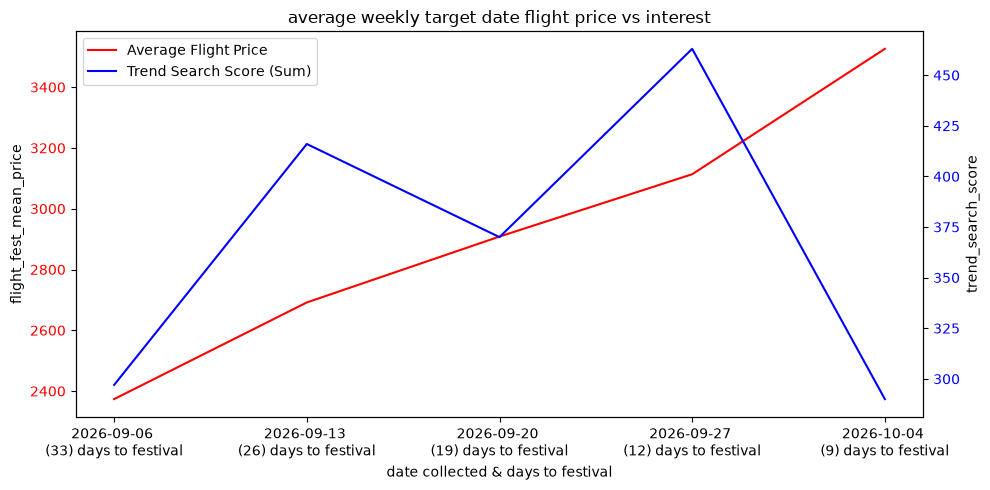

In [101]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_fest_mean_price'], 
    label='Average Flight Price', 
    color='red')
ax1.set_xlabel('date collected & days to festival')
ax1.set_ylabel('flight_fest_mean_price')
ax1.tick_params(axis='y', labelcolor='red')
# ax1.set_yinverted(True)

ax2 = ax1.twinx()

line2 = ax2.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['trend_search_score'],
    label='Trend Search Score (Sum)',
    color='blue')
ax2.set_ylabel('trend_search_score')
ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('average weekly target date flight price vs interest')
fig.tight_layout()
plt.show()

#### Interpretations
- Weekly average Target Date Flight price has consistently risen as the festival highlights gotten closer.
- Weekly Trends Score sum fluctuate, but have an upward trend. The dip nine days away from the festival is the result of incomplete live data (only three days data collected out of seven).

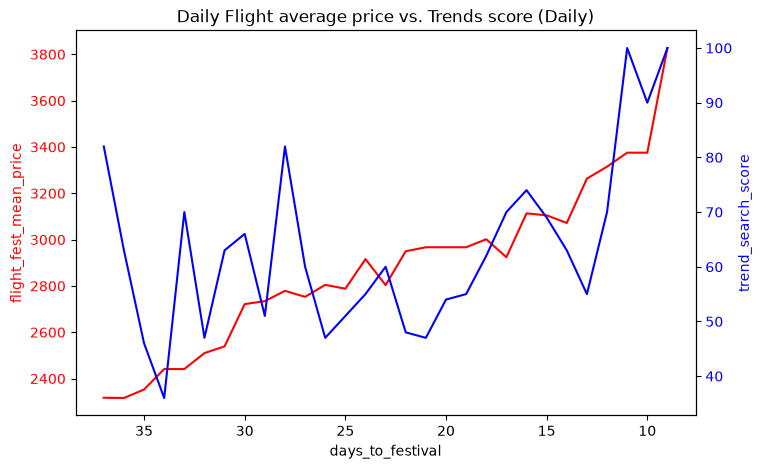

In [120]:
# 1. Create a Matplotlib figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(8, 5))

# 2. Plot the first variable on the primary axis (ax1)
sns.lineplot(
    data=df, 
    x='days_to_festival', 
    y='flight_fest_mean_price',
    ax=ax1, # <--- Pass ax1 here
    color='red',
    # line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2}
)
ax1.set_ylabel("flight_fest_mean_price", color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 3. Create a secondary y-axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# 4. Plot the second variable on the secondary axis (ax2)
sns.lineplot(
    data=df, 
    x='days_to_festival', 
    y='trend_search_score', # Change to your second column name
    ax=ax2, # <--- Pass ax2 here
    color='blue',
    # line_kws={'color': 'green', 'linestyle': '-', 'linewidth': 2}
)
ax2.set_ylabel("trend_search_score", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 5. Invert the x-axis (since they share an x-axis, inverting ax1 inverts both)
ax1.invert_xaxis()

plt.title("Daily Flight average price vs. Trends score (Daily)")
plt.xlabel("days_to_festival")
plt.show()

##### The daily equivalent to showcase more granularity than the weekly overview. Not formally analyzed due to weekly aggregation being preffered for insights.

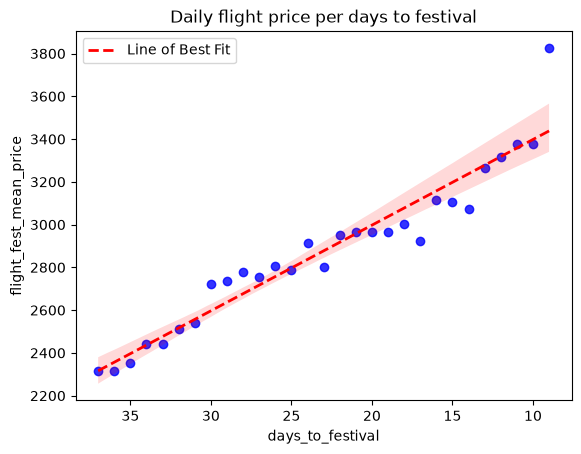

In [102]:
sns.regplot(
    data=df, 
    x='days_to_festival', 
    y='flight_fest_mean_price',
    color='blue',
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Line of Best Fit'}
)

plt.title("Daily flight price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("flight_fest_mean_price")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

#### Interpretations
- Daily average Target Date Flight price has a clear upward trend as the festival highlight date got closer.

C:\Users\gratu\AppData\Local\Temp\ipykernel_24424\2402450797.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


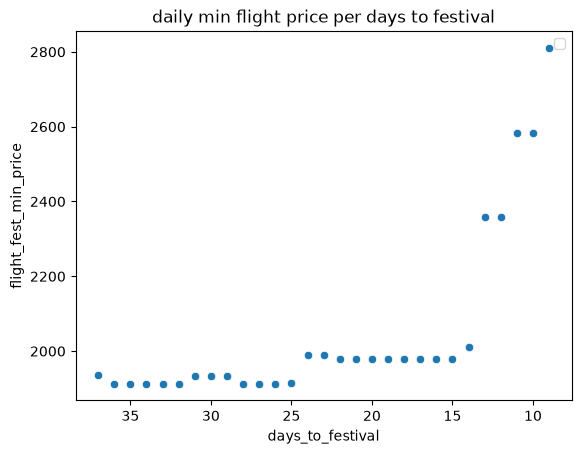

In [103]:
# plt.scatter(df['days_to_festival'], df['flight_fest_min_price'])

# plt.title("daily min flight price per days to festival")
# plt.xlabel("days_to_festival")
# plt.ylabel("flight_fest_min_price")

# plt.gca().invert_xaxis()
# plt.show()

sns.scatterplot(
    data=df, 
    x='days_to_festival', 
    y='flight_fest_min_price',
    # color='blue',
    # line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Line of Best Fit'}
)

plt.title("daily min flight price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("flight_fest_min_price")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

#### Interpretations
- Daily minimum flight price remained consistent until fifteen days away from the festival highlight, with a relatively small jump after twenty five days from the festival, and a significant surge after fifteen days.

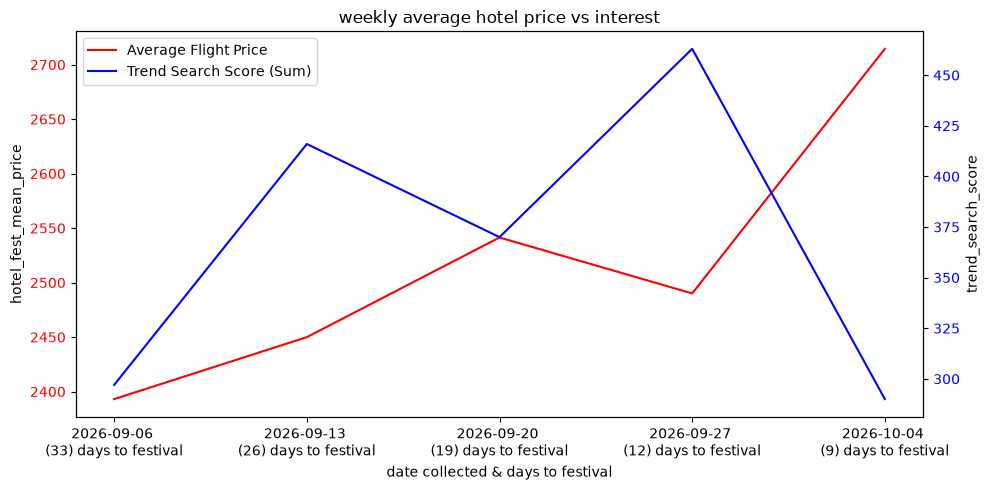

In [104]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_fest_mean_price'], 
    label='Average Flight Price', 
    color='red')
ax1.set_xlabel('date collected & days to festival')
ax1.set_ylabel('hotel_fest_mean_price')
ax1.tick_params(axis='y', labelcolor='red')
# ax1.set_yinverted(True)

ax2 = ax1.twinx()

line2 = ax2.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['trend_search_score'],
    label='Trend Search Score (Sum)',
    color='blue')
ax2.set_ylabel('trend_search_score')
ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('weekly average hotel price vs interest')
fig.tight_layout()
plt.show()

#### Interpretations
- Trends interest show an upwards trends for the four observed weeks, with the drop nine days away being an artefact of a yet-incomplete three out of seven days data collection.
- Alongside the trend, the average flight price has also consistently risen. 
- A data point of interest would be the average flight price surge twelve days away from the festival; pending the completion of the fith week's data, it would be interesting to investigate if the google trend's search interest surged before, after, or alongside the price.

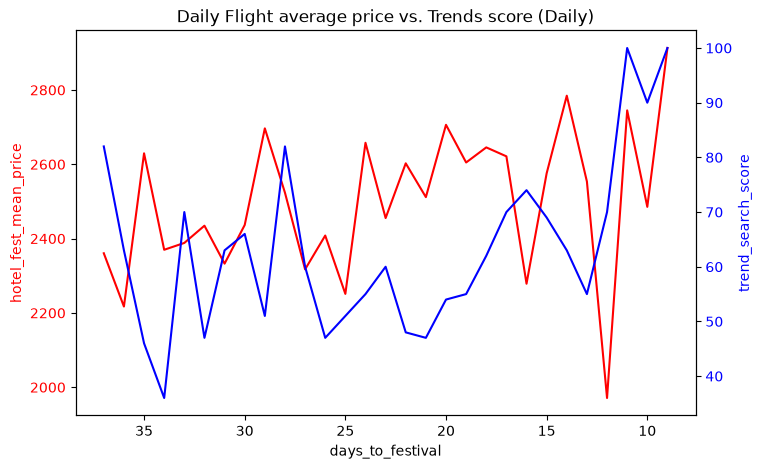

In [121]:
# 1. Create a Matplotlib figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(8, 5))

# 2. Plot the first variable on the primary axis (ax1)
sns.lineplot(
    data=df, 
    x='days_to_festival', 
    y='hotel_fest_mean_price',
    ax=ax1, # <--- Pass ax1 here
    color='red',
    # line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2}
)
ax1.set_ylabel("hotel_fest_mean_price", color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 3. Create a secondary y-axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# 4. Plot the second variable on the secondary axis (ax2)
sns.lineplot(
    data=df, 
    x='days_to_festival', 
    y='trend_search_score', # Change to your second column name
    ax=ax2, # <--- Pass ax2 here
    color='blue',
    # line_kws={'color': 'green', 'linestyle': '-', 'linewidth': 2}
)
ax2.set_ylabel("trend_search_score", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 5. Invert the x-axis (since they share an x-axis, inverting ax1 inverts both)
ax1.invert_xaxis()

plt.title("Daily Flight average price vs. Trends score (Daily)")
plt.xlabel("days_to_festival")
plt.show()

##### The daily equivalent to showcase more granularity than the weekly overview. Not formally analyzed due to weekly aggregation being preffered for insights.

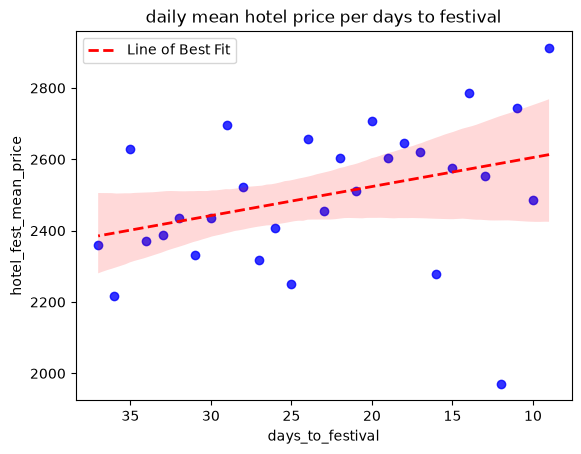

In [105]:
# x = df['days_to_festival']
# y = df['hotel_fest_mean_price']

# plt.scatter(x, y)
# m, b = np.polyfit(x, y, 1)

# plt.title("daily mean hotel price per days to festival")
# plt.xlabel("days_to_festival")
# plt.ylabel("hotel_fest_mean_price")

# x_sorted = np.sort(x)
# plt.plot(x_sorted, m * x_sorted + b, color='red', linestyle='--', linewidth=2, label='Line of Best Fit')

# plt.gca().invert_xaxis()
# plt.show()

sns.regplot(
    data=df, 
    x='days_to_festival', 
    y='hotel_fest_mean_price',
    color='blue',
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Line of Best Fit'}
)

plt.title("daily mean hotel price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("hotel_fest_mean_price")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

#### Interpretations
- Daily mean Hotel Prices are highly volatile, with an upwards trend.

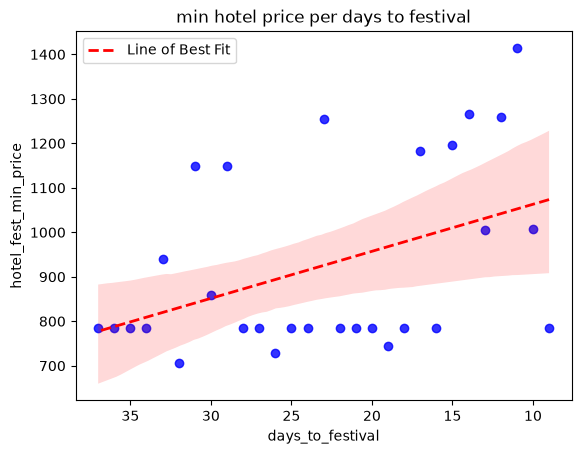

In [106]:
# plt.scatter(df['days_to_festival'], df['hotel_fest_min_price'])

# plt.title("min hotel price per days to festival")
# plt.xlabel("days_to_festival")
# plt.ylabel("hotel_fest_min_price")

# plt.gca().invert_xaxis()
# plt.show()

sns.regplot(
    data=df, 
    x='days_to_festival', 
    y='hotel_fest_min_price',
    color='blue',
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Line of Best Fit'}
)

plt.title("min hotel price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("hotel_fest_min_price")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

#### Interpretations
- Daily minimum Hotel nightly stay Target Date price frequently land below 800, but experienced surges within the 34th and 29th day from the festival, and another, ongoing surge around 15 days away.
- Overall it has an upwards trend, with significant volatility.

#### Trends as festival gets closer

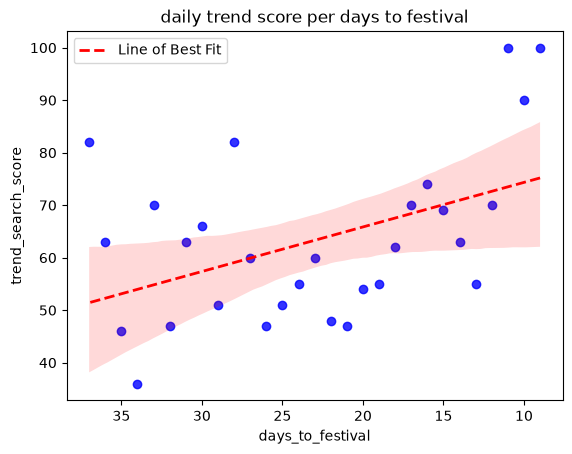

In [107]:
# plt.scatter(df['days_to_festival'], df['trend_search_score'])

# plt.title("daily trend score per days to festival")
# plt.xlabel("days_to_festival")
# plt.ylabel("trend_search_score")

# plt.gca().invert_xaxis()
# plt.show()

sns.regplot(
    data=df, 
    x='days_to_festival', 
    y='trend_search_score',
    color='blue',
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Line of Best Fit'}
)

plt.title("daily trend score per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("trend_search_score")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

#### Interpretations
- The daily trend score was volitile until 26 days away where it showed a consistent upwards trend and experienced a surge around 13 days away from the festival.

#### Rolling vs Target date price

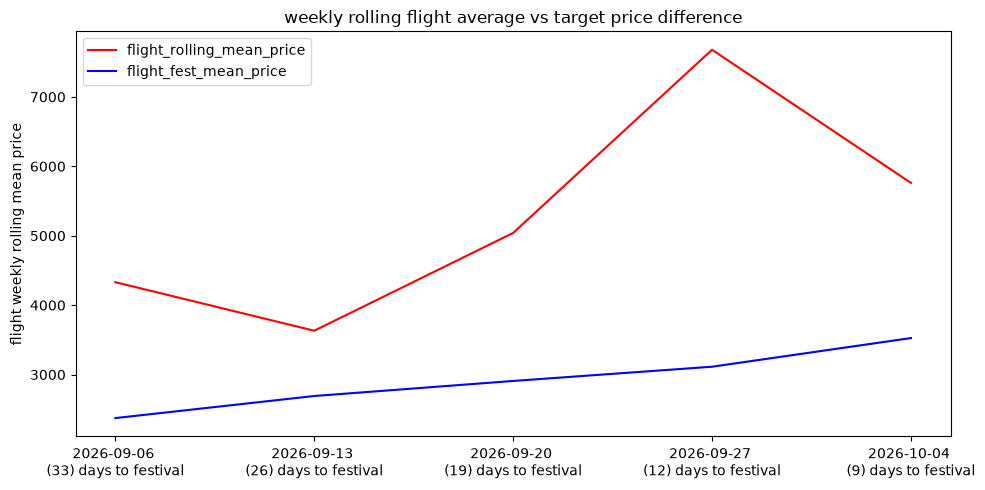

In [108]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_rolling_mean_price'], 
    label='flight_rolling_mean_price', 
    color='red')
ax1.set_ylabel('flight weekly rolling mean price')
ax1.tick_params(axis='y')
# ax1.set_yinverted(True)


line2 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_fest_mean_price'],
    label='flight_fest_mean_price',
    color='blue')
ax1.tick_params(axis='y')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('weekly rolling flight average vs target price difference')
fig.tight_layout()
plt.show()

#### Interpretations
- Rolling flight prices tend to be higher than the target date prices, but both are trending upwards as the festival gets closer. The two metrics do not appear to corrolate as while the rolling price is volatile with an upwards trend, the target date price has a largely steady rise in price.

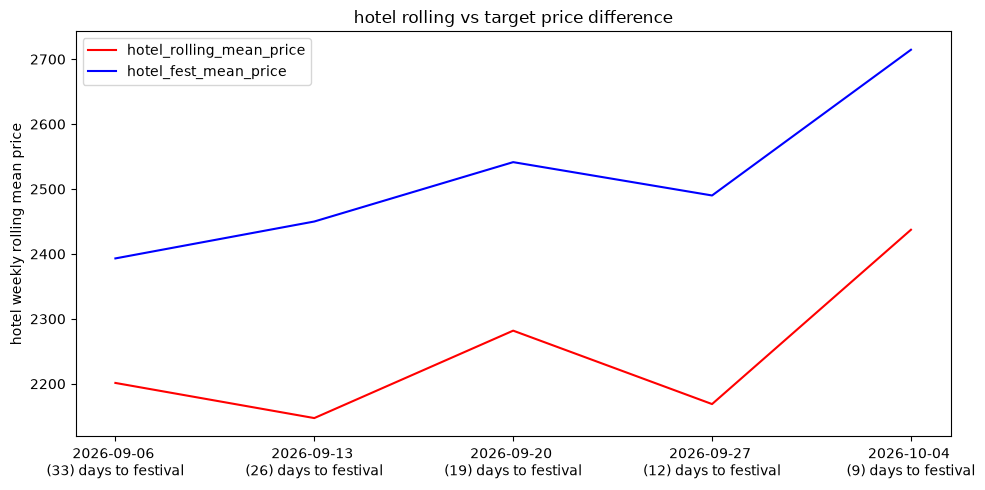

In [109]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_rolling_mean_price'], 
    label='hotel_rolling_mean_price', 
    color='red')
ax1.set_ylabel('hotel weekly rolling mean price')
ax1.tick_params(axis='y')
# ax1.set_yinverted(True)


line2 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_fest_mean_price'],
    label='hotel_fest_mean_price',
    color='blue')
ax1.tick_params(axis='y')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('hotel rolling vs target price difference')
fig.tight_layout()
plt.show()

#### Interpretations
- Rolling hotel prices is lower than the target date prices, but both are trending upwards as the festival gets closer. Both metrics appear to corrolate, with peaks and dips largely matching between the two metrics.